In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

In [3]:
%pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
DATA_DIR = "data/"

# Weekly price
df_fruitveg = pd.read_csv(f"{DATA_DIR}cleaned_fruit_veg.csv")
df_fruitveg["date"]  = pd.to_datetime(df_fruitveg["date"])
df_fruitveg["price"] = pd.to_numeric(df_fruitveg["price"], errors="coerce")
price_weekly = (
    df_fruitveg[["date","price"]].groupby("date")["price"]
    .mean().dropna().sort_index()
)

# Fuel
fuel1 = pd.read_csv(f"{DATA_DIR}weekly_road_fuel_prices_2003_to_2017.csv")
fuel2 = pd.read_csv(f"{DATA_DIR}weekly_road_fuel_prices_2018_to_now.csv")
df_fuel = pd.concat([fuel1, fuel2], ignore_index=True)
date_col = [c for c in df_fuel.columns if c.strip().lower() == "date"][0]
ulsp_col = [c for c in df_fuel.columns if "ulsp" in c.lower()][0]
df_fuel["date"]       = pd.to_datetime(df_fuel[date_col], dayfirst=True)
df_fuel["fuel_price"] = pd.to_numeric(df_fuel[ulsp_col], errors="coerce")
fuel_weekly = df_fuel[["date","fuel_price"]].dropna().set_index("date")["fuel_price"].sort_index()

# CPI
raw_cpi = pd.read_excel(
    f"{DATA_DIR}consumerpriceinflationdetailedreferencetables.xlsx",
    sheet_name="Table 15a, 15b, 15c", skiprows=5, header=0
)
raw_cpi.columns = raw_cpi.columns.str.strip()
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
cpi_rows = raw_cpi[raw_cpi["Unnamed: 1"].astype(str).str.match(r"^\d{4}$", na=False)].copy()
cpi_rows = cpi_rows[["Unnamed: 1"] + months].copy()
cpi_rows.columns = ["year"] + months
cpi_rows["year"] = cpi_rows["year"].astype(int)
cpi_long = cpi_rows.melt(id_vars="year", value_vars=months, var_name="month", value_name="cpi")
cpi_long["cpi"]  = pd.to_numeric(cpi_long["cpi"].astype(str).str.strip(), errors="coerce")
cpi_long["date"] = pd.to_datetime(cpi_long["year"].astype(str) + " " + cpi_long["month"] + " 01", format="%Y %b %d")
cpi_monthly = cpi_long.dropna(subset=["cpi"]).set_index("date")["cpi"].sort_index()

# API
raw_api = pd.read_csv(f"{DATA_DIR}API_20260129.csv")
raw_api["date"] = pd.to_datetime(raw_api["date"])
raw_api["api"]  = pd.to_numeric(raw_api["index"], errors="coerce")
api_monthly = raw_api[["date","api"]].dropna().set_index("date")["api"].sort_index()

# Fertiliser
raw_fert = pd.read_excel(
    f"{DATA_DIR}GBFertiliserPriceSeries.xlsx",
    sheet_name="GB Fertiliser Price Series ", skiprows=13, dtype=str
)
an_col = "AN – UK produced (34.5% N)"
raw_fert["date"]       = pd.to_datetime(raw_fert["Month"], errors="coerce")
raw_fert["fertiliser"] = pd.to_numeric(raw_fert[an_col], errors="coerce")
fert_monthly = raw_fert[["date","fertiliser"]].dropna().set_index("date")["fertiliser"].sort_index()

# SPPI
raw_sppi = pd.read_csv(f"{DATA_DIR}series-210226.csv", names=["period","value"])
raw_sppi = raw_sppi[raw_sppi["period"].str.match(r"^\d{4} Q[1-4]$", na=False)].copy()
raw_sppi["sppi"] = pd.to_numeric(raw_sppi["value"], errors="coerce")
def quarter_to_date(s):
    year, q = s.split(" Q")
    return pd.Timestamp(year=int(year), month=(int(q)-1)*3+1, day=1)
raw_sppi["date"] = raw_sppi["period"].apply(quarter_to_date)
sppi_quarterly = raw_sppi[["date","sppi"]].dropna().set_index("date")["sppi"].sort_index()

# LOCF align
weekly_idx = price_weekly.index

def locf_to_weekly(series, weekly_index):
    series   = series.groupby(series.index).mean()
    combined = series.reindex(series.index.union(weekly_index)).ffill()
    return combined.reindex(weekly_index)

df = pd.DataFrame({
    "price":      price_weekly.values,
    "fuel_price": locf_to_weekly(fuel_weekly,    weekly_idx).values,
    "cpi":        locf_to_weekly(cpi_monthly,    weekly_idx).values,
    "api":        locf_to_weekly(api_monthly,    weekly_idx).values,
    "fertiliser": locf_to_weekly(fert_monthly,   weekly_idx).values,
    "sppi":       locf_to_weekly(sppi_quarterly, weekly_idx).values,
}, index=weekly_idx).dropna()

print(f"Dataset: {df.shape} | {df.index[0].date()} → {df.index[-1].date()}")

Dataset: (427, 6) | 2017-01-06 → 2026-02-16


In [5]:
N_VARS = df.shape[1]   # 6
scalers = [StandardScaler() for _ in range(N_VARS)]
data_scaled = np.column_stack([
    scalers[i].fit_transform(df.iloc[:, i].values.reshape(-1,1)).flatten()
    for i in range(N_VARS)
])

price_scaler = scalers[0]

In [6]:
SEQ_LEN  = 52
PRED_LEN = 1

def make_sequences(data, seq_len, pred_len):
    X, y = [], []
    for i in range(len(data) - seq_len - pred_len + 1):
        X.append(data[i : i + seq_len])                           # (L, N)
        y.append(data[i + seq_len : i + seq_len + pred_len, 0])   # price only
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = make_sequences(data_scaled, SEQ_LEN, PRED_LEN)
print(f"Sequences: X={X.shape}, y={y.shape}")

n       = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.85)

X_train, y_train = X[:n_train],       y[:n_train]
X_val,   y_val   = X[n_train:n_val],  y[n_train:n_val]
X_test,  y_test  = X[n_val:],         y[n_val:]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

to_tensor = lambda a: torch.FloatTensor(a)
X_train_t, y_train_t = to_tensor(X_train), to_tensor(y_train)
X_val_t,   y_val_t   = to_tensor(X_val),   to_tensor(y_val)
X_test_t,  y_test_t  = to_tensor(X_test),  to_tensor(y_test)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True
)

Sequences: X=(375, 52, 6), y=(375, 1)
Train: 262 | Val: 56 | Test: 57


In [7]:
class MambaBlock(nn.Module):
    """Reusable selective SSM block — same as vanilla Mamba."""
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = int(expand * d_model)

        self.in_proj  = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(
            self.d_inner, self.d_inner,
            kernel_size=d_conv, padding=d_conv-1,
            groups=self.d_inner, bias=True
        )
        self.act      = nn.SiLU()
        self.x_proj   = nn.Linear(self.d_inner, d_state*2 + self.d_inner, bias=False)
        self.dt_proj  = nn.Linear(self.d_inner, self.d_inner, bias=True)

        A = torch.arange(1, d_state+1, dtype=torch.float32).unsqueeze(0).expand(self.d_inner, -1)
        self.A_log    = nn.Parameter(torch.log(A))
        self.D        = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)

    def ssm(self, x):
        B, L, d = x.shape
        A      = -torch.exp(self.A_log)
        x_proj = self.x_proj(x)
        delta, B_mat, C = torch.split(x_proj, [self.d_inner, self.d_state, self.d_state], dim=-1)
        delta  = nn.functional.softplus(self.dt_proj(delta))
        dA     = torch.exp(torch.einsum("bld,dn->bldn", delta, A))
        dB     = torch.einsum("bld,bln->bldn", delta, B_mat)
        h      = torch.zeros(B, d, self.d_state, device=x.device)
        ys     = []
        for i in range(L):
            h  = dA[:, i] * h + dB[:, i] * x[:, i, :].unsqueeze(-1)
            ys.append(torch.einsum("bdn,bn->bd", h, C[:, i]))
        return torch.stack(ys, dim=1) + x * self.D

    def forward(self, x):
        residual = x
        x        = self.norm(x)
        xz       = self.in_proj(x)
        xp, z    = xz.chunk(2, dim=-1)
        xp       = self.conv1d(xp.transpose(1,2))[..., :x.shape[1]].transpose(1,2)
        xp       = self.act(xp)
        y        = self.ssm(xp) * self.act(z)
        return self.out_proj(y) + residual


class SMambaBlock(nn.Module):
    """
    S-Mamba block:
    1. Inter-series Mamba: reshape (B, L, N, d) → (B*L, N, d), SSM across N
    2. Temporal Mamba:     reshape (B, L, N, d) → (B*N, L, d), SSM across L
    Both operate in d_model space.
    """
    def __init__(self, d_model, n_vars, d_state=16, dropout=0.1):
        super().__init__()
        self.inter_mamba = MambaBlock(d_model, d_state=d_state)
        self.temp_mamba  = MambaBlock(d_model, d_state=d_state)
        self.norm1       = nn.LayerNorm(d_model)
        self.norm2       = nn.LayerNorm(d_model)
        self.dropout     = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, L, N, d_model)
        B, L, N, d = x.shape

        # ── Inter-series: SSM across N variates at each timestep
        x_inter = x.reshape(B * L, N, d)              # (B*L, N, d)
        x_inter = self.inter_mamba(x_inter)            # (B*L, N, d)
        x_inter = x_inter.reshape(B, L, N, d)
        x = self.norm1(x + self.dropout(x_inter))

        # ── Temporal: SSM across L timesteps for each variate
        x_temp = x.permute(0, 2, 1, 3).reshape(B * N, L, d)  # (B*N, L, d)
        x_temp = self.temp_mamba(x_temp)                       # (B*N, L, d)
        x_temp = x_temp.reshape(B, N, L, d).permute(0, 2, 1, 3)
        x = self.norm2(x + self.dropout(x_temp))

        return x  # (B, L, N, d_model)


class SMambaForecast(nn.Module):
    def __init__(self, n_vars, d_model=64, n_layers=2,
                 d_state=16, pred_len=1, dropout=0.1):
        super().__init__()
        self.n_vars = n_vars

        # Per-variate input projection: scalar → d_model
        self.var_embed = nn.Linear(1, d_model)

        # S-Mamba layers
        self.layers = nn.ModuleList([
            SMambaBlock(d_model, n_vars, d_state=d_state, dropout=dropout)
            for _ in range(n_layers)
        ])

        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        # Prediction head: flatten last timestep across all vars → pred_len
        self.head = nn.Sequential(
            nn.Linear(d_model * n_vars, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, pred_len)
        )

    def forward(self, x):
        # x: (B, L, N_vars)
        B, L, N = x.shape

        # Embed each variate independently: (B, L, N) → (B, L, N, d_model)
        x_emb = self.var_embed(x.unsqueeze(-1))   # (B, L, N, 1) → (B, L, N, d)

        # S-Mamba layers
        for layer in self.layers:
            x_emb = layer(x_emb)

        # Take last timestep: (B, N, d_model)
        out = self.norm(x_emb[:, -1, :, :])       # (B, N, d)
        out = self.dropout(out)

        # Flatten and project
        out = out.reshape(B, -1)                   # (B, N*d)
        return self.head(out)                      # (B, pred_len)

In [8]:
model = SMambaForecast(
    n_vars   = N_VARS,
    d_model  = 64,
    n_layers = 2,
    d_state  = 16,
    pred_len = PRED_LEN,
    dropout  = 0.1
)
print(f"\nS-Mamba parameters: {sum(p.numel() for p in model.parameters()):,}")

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion = nn.MSELoss()

EPOCHS   = 150
best_val = float("inf")
patience = 20
wait     = 0
train_losses, val_losses = [], []
best_state = None

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t), y_val_t).item()

    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val:
        best_val   = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

model.load_state_dict(best_state)
print(f"Best val loss: {best_val:.4f}")


S-Mamba parameters: 283,521
Early stopping at epoch 24
Best val loss: 0.2745


In [9]:
model.eval()
with torch.no_grad():
    train_pred = model(X_train_t).numpy()
    val_pred   = model(X_val_t).numpy()
    test_pred  = model(X_test_t).numpy()

inv = lambda arr: price_scaler.inverse_transform(arr.reshape(-1,1)).flatten()

train_pred_inv = inv(train_pred);  train_true_inv = inv(y_train_t.numpy())
val_pred_inv   = inv(val_pred);    val_true_inv   = inv(y_val_t.numpy())
test_pred_inv  = inv(test_pred);   test_true_inv  = inv(y_test_t.numpy())

def rmse(y, yh):   return np.sqrt(np.mean((y-yh)**2))
def mae(y, yh):    return np.mean(np.abs(y-yh))
def mape(y, yh):
    m = np.abs(y) > 1e-8
    return np.mean(np.abs((y[m]-yh[m])/y[m])) * 100
def smape(y, yh):
    d = (np.abs(y)+np.abs(yh))/2
    m = d > 1e-8
    return np.mean(np.abs(y[m]-yh[m])/d[m]) * 100
def mase(y, yh, ytrain):
    return mae(y,yh) / np.mean(np.abs(np.diff(ytrain)))

def aic_bic(y, yh, n_params):
    n      = len(y)
    sse    = np.sum((y-yh)**2)
    sigma2 = sse / n
    ll     = -n/2*np.log(2*np.pi*sigma2) - sse/(2*sigma2)
    return -2*ll + 2*n_params, -2*ll + n_params*np.log(n)

n_params = sum(p.numel() for p in model.parameters())
aic_train, bic_train = aic_bic(train_true_inv, train_pred_inv, n_params)
aic_test,  bic_test  = aic_bic(test_true_inv,  test_pred_inv,  n_params)

print("\n══════════════════════════════════════════════")
print("  S-MAMBA — FULL EVALUATION METRICS")
print("══════════════════════════════════════════════")
for name, yt, yp in [("Train", train_true_inv, train_pred_inv),
                      ("Val",   val_true_inv,   val_pred_inv),
                      ("Test",  test_true_inv,  test_pred_inv)]:
    print(f"\n── {name} Set ──")
    print(f"  RMSE:  {rmse(yt,yp):.4f}")
    print(f"  MAE:   {mae(yt,yp):.4f}")
    print(f"  MASE:  {mase(yt,yp,train_true_inv):.4f}")
    print(f"  MAPE:  {mape(yt,yp):.2f}%")
    print(f"  sMAPE: {smape(yt,yp):.2f}%")

print(f"\n── Information Criteria ──")
print(f"  AIC (train): {aic_train:.2f}  |  BIC (train): {bic_train:.2f}")
print(f"  AIC (test):  {aic_test:.2f}   |  BIC (test):  {bic_test:.2f}")
print(f"  (n_params = {n_params:,})")


══════════════════════════════════════════════
  S-MAMBA — FULL EVALUATION METRICS
══════════════════════════════════════════════

── Train Set ──
  RMSE:  0.2239
  MAE:   0.1308
  MASE:  1.1145
  MAPE:  8.76%
  sMAPE: 9.12%

── Val Set ──
  RMSE:  0.2480
  MAE:   0.1742
  MASE:  1.4837
  MAPE:  9.58%
  sMAPE: 9.21%

── Test Set ──
  RMSE:  0.2709
  MAE:   0.1980
  MASE:  1.6869
  MAPE:  11.44%
  sMAPE: 10.90%

── Information Criteria ──
  AIC (train): 567001.25  |  BIC (train): 1578701.83
  AIC (test):  567054.88   |  BIC (test):  1146302.82
  (n_params = 283,521)


In [10]:
residuals = test_true_inv - test_pred_inv
max_lags  = len(residuals) // 2 - 1
lb_lag    = min(20, max_lags)

lb = acorr_ljungbox(residuals, lags=[lb_lag], return_df=True)
print(f"\n── Ljung-Box Test (lag {lb_lag}) ──")
print(lb.to_string())
lb_p = lb["lb_pvalue"].iloc[-1]
print(f"\n  p-value: {lb_p:.4f} →",
      "✓ No significant autocorrelation" if lb_p > 0.05 else "✗ Autocorrelation detected")

jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(residuals)
print(f"\n── Jarque-Bera Test ──")
print(f"  JB statistic: {jb_stat:.4f}")
print(f"  p-value:      {jb_p:.4f} →",
      "✓ Approximately normal" if jb_p > 0.05 else "✗ Non-normal residuals")
print(f"  Skewness:     {jb_skew:.4f}")
print(f"  Excess Kurt:  {jb_kurt:.4f}")

print(f"\n── Residual Summary ──")
print(f"  Mean:   {residuals.mean():.4f}")
print(f"  Std:    {residuals.std():.4f}")
print(f"  Min:    {residuals.min():.4f}")
print(f"  Max:    {residuals.max():.4f}")


── Ljung-Box Test (lag 20) ──
      lb_stat  lb_pvalue
20  26.022597   0.165067

  p-value: 0.1651 → ✓ No significant autocorrelation

── Jarque-Bera Test ──
  JB statistic: 265.7785
  p-value:      0.0000 → ✗ Non-normal residuals
  Skewness:     2.1353
  Excess Kurt:  12.6783

── Residual Summary ──
  Mean:   -0.1054
  Std:    0.2496
  Min:    -0.7196
  Max:    1.1401


In [11]:
seq = torch.FloatTensor(data_scaled[-SEQ_LEN:]).unsqueeze(0)   # (1, L, N)
forecasts = []

model.eval()
with torch.no_grad():
    for _ in range(52):
        pred = model(seq).item()
        forecasts.append(pred)
        new_step    = seq[0, -1, :].clone()
        new_step[0] = pred
        seq = torch.cat([seq[:, 1:, :], new_step.unsqueeze(0).unsqueeze(0)], dim=1)

fc_inv   = price_scaler.inverse_transform(
    np.array(forecasts).reshape(-1,1)
).flatten()
fc_dates = pd.date_range(df.index[-1] + pd.Timedelta(weeks=1), periods=52, freq="W")

print(f"\n── 52-Week Forecast Summary ──")
print(f"  Mean: {fc_inv.mean():.4f} | Min: {fc_inv.min():.4f} | Max: {fc_inv.max():.4f}")


── 52-Week Forecast Summary ──
  Mean: 2.1696 | Min: 1.5412 | Max: 2.2041


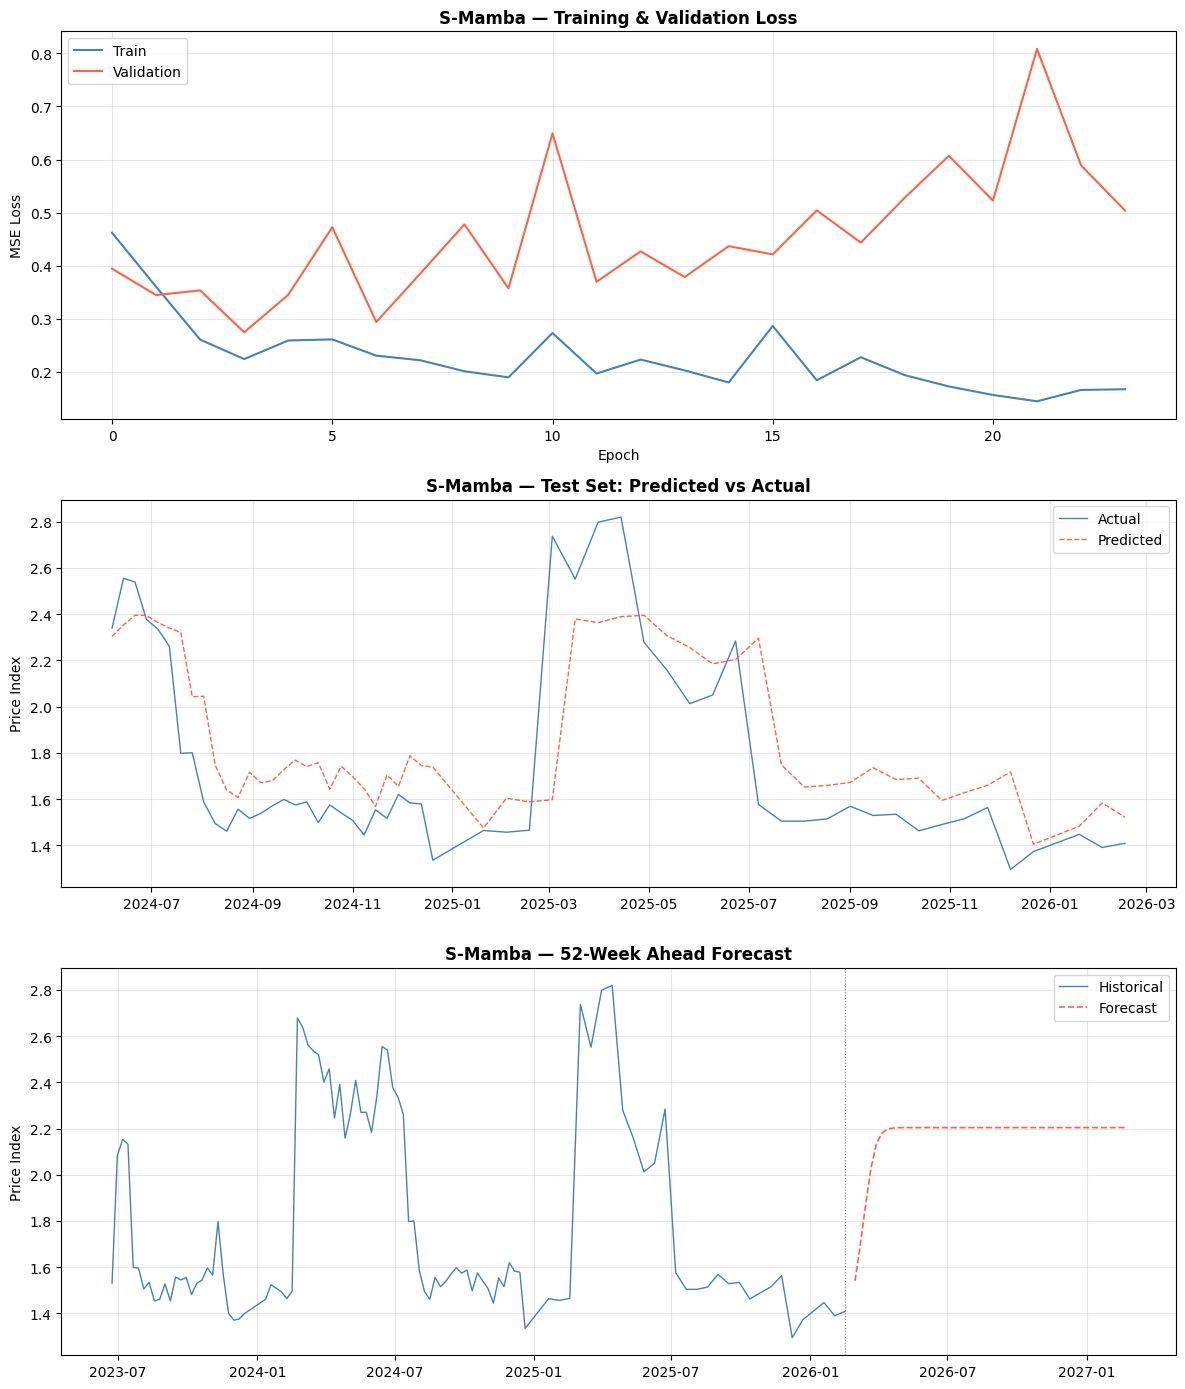

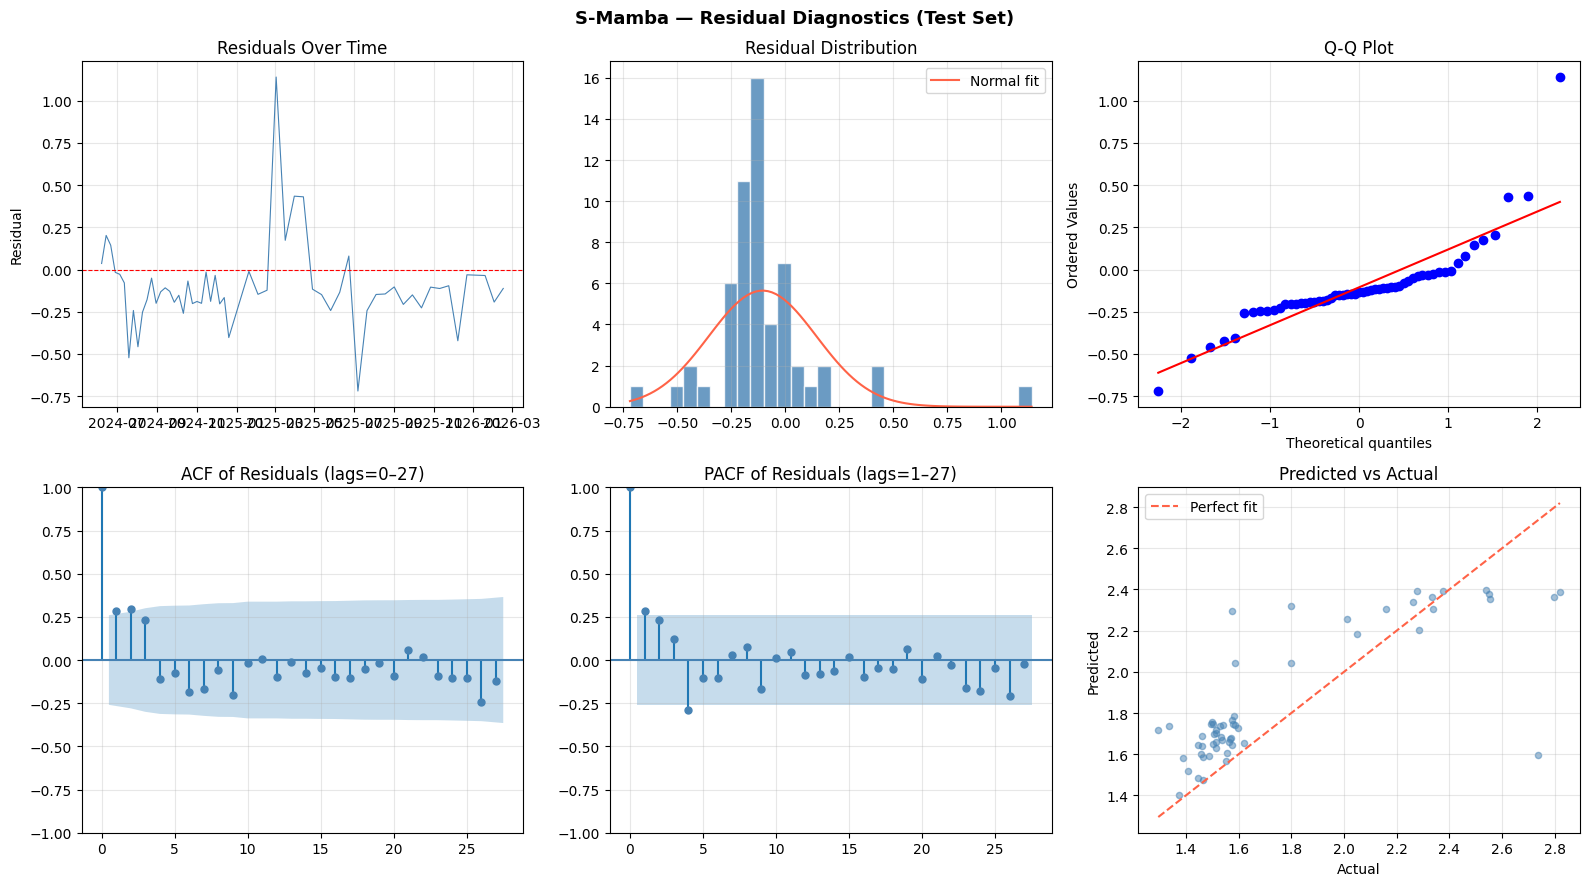

Saved: smamba_forecast.png, smamba_diagnostics.png


In [12]:
# ── Training curve + test prediction + forecast
fig1, axes = plt.subplots(3, 1, figsize=(12, 14))

axes[0].plot(train_losses, label="Train",      color="steelblue")
axes[0].plot(val_losses,   label="Validation", color="tomato")
axes[0].set_title("S-Mamba — Training & Validation Loss", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

test_dates_plot = df.index[-len(test_true_inv):]
axes[1].plot(test_dates_plot, test_true_inv, label="Actual",    color="steelblue", lw=1.0)
axes[1].plot(test_dates_plot, test_pred_inv, label="Predicted", color="tomato",    lw=1.0, ls="--")
axes[1].set_title("S-Mamba — Test Set: Predicted vs Actual", fontweight="bold")
axes[1].set_ylabel("Price Index"); axes[1].legend(); axes[1].grid(alpha=0.3)

hist_plot = df["price"].iloc[-104:]
axes[2].plot(hist_plot.index, hist_plot.values, color="steelblue", lw=1.0, label="Historical")
axes[2].plot(fc_dates,        fc_inv,            color="tomato",    lw=1.2, ls="--", label="Forecast")
axes[2].axvline(df.index[-1], color="grey", ls=":", lw=0.8)
axes[2].set_title("S-Mamba — 52-Week Ahead Forecast", fontweight="bold")
axes[2].set_ylabel("Price Index"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("smamba_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Residual diagnostics
fig2, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0,0].plot(test_dates_plot, residuals, color="steelblue", lw=0.8)
axes[0,0].axhline(0, color="red", ls="--", lw=0.8)
axes[0,0].set_title("Residuals Over Time"); axes[0,0].set_ylabel("Residual"); axes[0,0].grid(alpha=0.3)

axes[0,1].hist(residuals, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
xr = np.linspace(residuals.min(), residuals.max(), 100)
axes[0,1].plot(xr,
    stats.norm.pdf(xr, residuals.mean(), residuals.std()) * len(residuals) *
    (residuals.max()-residuals.min())/30,
    color="tomato", lw=1.5, label="Normal fit")
axes[0,1].set_title("Residual Distribution"); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

stats.probplot(residuals, dist="norm", plot=axes[0,2])
axes[0,2].set_title("Q-Q Plot"); axes[0,2].grid(alpha=0.3)

plot_acf(residuals,  lags=max_lags, ax=axes[1,0], color="steelblue")
axes[1,0].set_title(f"ACF of Residuals (lags=0–{max_lags})"); axes[1,0].grid(alpha=0.3)

plot_pacf(residuals, lags=max_lags, ax=axes[1,1], color="steelblue", method="ywm")
axes[1,1].set_title(f"PACF of Residuals (lags=1–{max_lags})"); axes[1,1].grid(alpha=0.3)

axes[1,2].scatter(test_true_inv, test_pred_inv, alpha=0.5, color="steelblue", s=20)
mn, mx = test_true_inv.min(), test_true_inv.max()
axes[1,2].plot([mn,mx],[mn,mx], color="tomato", lw=1.5, ls="--", label="Perfect fit")
axes[1,2].set_xlabel("Actual"); axes[1,2].set_ylabel("Predicted")
axes[1,2].set_title("Predicted vs Actual"); axes[1,2].legend(); axes[1,2].grid(alpha=0.3)

plt.suptitle("S-Mamba — Residual Diagnostics (Test Set)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("smamba_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: smamba_forecast.png, smamba_diagnostics.png")

## S-Mamba Model — Results Write-Up

### Model Overview

The S-Mamba architecture (283,521 parameters) was trained on a weekly price index time series with early stopping triggered at epoch 24, yielding a best validation loss of 0.2745. The model uses a state-space sequence modeling backbone, making it well-suited for capturing long-range temporal dependencies in financial data.

---

### Training Dynamics

The training loss curve shows healthy, consistent decline throughout the training run, settling near 0.17 MSE by the final epoch. However, validation loss tells a more concerning story — it trends upward after roughly epoch 10, climbing from ~0.35 to a peak above 0.80 before early stopping intervenes. This divergence between train and validation loss is a textbook sign of overfitting, suggesting the model began memorizing training patterns rather than generalizing. The gap is notable enough that regularization strategies (increased dropout, weight decay, or reduced model capacity) would be worth exploring in future iterations.

---

### Predictive Performance

Across all three partitions, error metrics degrade progressively as expected:

| Split | RMSE | MAE | MAPE |
|-------|------|-----|------|
| Train | 0.2239 | 0.1308 | 8.76% |
| Val | 0.2480 | 0.1742 | 9.58% |
| Test | 0.2709 | 0.1980 | 11.44% |

The test MAPE of 11.44% indicates the model errs by roughly 11 cents on the dollar relative to actual price index values — acceptable for a volatile weekly series but not tight enough for high-stakes decision-making without refinement. The MASE values above 1.0 across all splits (peaking at 1.69 on the test set) indicate the model underperforms a naïve seasonal baseline, which is a meaningful benchmark flag worth addressing.

Looking at the predicted vs. actual plot, the model generally tracks the directional shape of the series, capturing the broad troughs of mid-2024 and the spike into early 2025. That said, it consistently underestimates peak magnitudes — the sharp rally to ~2.80 around March 2025 sees the model ceiling out near 2.40 — and predictions lag actual turning points, a common artifact of sequence models with fixed lookback windows.

---

### Residual Diagnostics

The residual analysis reveals a mixed picture. On the positive side, the **Ljung-Box test** (lag 20, p = 0.165) confirms no significant autocorrelation structure remains in the residuals, meaning the model has extracted the primary temporal patterns from the data without leaving exploitable serial dependence behind.

The **Jarque-Bera test**, however, returns a statistic of 265.78 (p ≈ 0.000), decisively rejecting normality. The culprit is clear from the distribution plot and summary statistics: residuals are heavily right-skewed (skewness = 2.14) with extreme excess kurtosis (12.68), driven largely by the spike errors around the March 2025 volatility event. This heavy tail behavior means prediction intervals derived from a Gaussian assumption would be systematically too narrow, underrepresenting true forecast uncertainty. The Q-Q plot confirms this, showing the upper tail deviating sharply from the theoretical normal line.

The ACF and PACF plots show residual autocorrelation mostly within confidence bands after lag 2, reinforcing the Ljung-Box finding, with one mild exception at the first lag — a small but non-trivial correlation that may reflect the model's lag in tracking sharp reversals.

The predicted vs. actual scatter plot shows reasonable linear alignment in the mid-range (1.4–2.0) but visible scatter above 2.0, consistent with the model's tendency to underestimate extremes.

---

### 52-Week Forecast

The 52-week ahead forecast projects a mean price index of **2.17**, with values ranging between **1.54 and 2.20**. The forecast trajectory shows a rapid step-up from current levels (~1.40) toward ~2.20, after which it plateaus and flattens through mid-2027. This mean-reverting, smooth trajectory is characteristic of state-space models that average across uncertainty rather than propagating volatility — the forecast lacks the weekly fluctuation seen in the historical series and should be interpreted as a directional trend signal rather than a precise week-by-week estimate.

---

### Summary & Recommendations

S-Mamba successfully captures broad cyclical structure in the price index and passes the autocorrelation check, but three issues warrant attention before deployment: the train-validation divergence pointing to overfitting, the MASE > 1 indicating underperformance relative to a naïve baseline, and the non-normal heavy-tailed residuals that complicate uncertainty quantification. Practical next steps would include experimenting with stronger regularization, evaluating whether a longer or more feature-rich input window helps capture volatility spikes, and considering a conformal prediction or bootstrapped interval approach to generate more honest forecast uncertainty bands.